In [2]:
"""
xLSTM for BiH air-quality forecasting.

Wires into the real bih_shared.py (from shared_setup.ipynb), which exposes:
    load_split, load_groups, load_windows, load_coords, load_panel,
    target, context, mase_scale, score, aggregate

Key thing this respects that a naive port wouldn't: eval_windows.csv is
VALIDATION-ONLY (origins are drawn only from 2024, midnight, one per day).
There is no equivalent frozen file for training windows, so training
origins are built here with the *same* eligibility rule the notebook uses
for eval (min_real_target_hours, some real history in the preceding week),
just applied to the 2021-2023 train range instead. That keeps train/val
windowing philosophy identical without inventing a second convention.
"""

import os
import sys
import subprocess
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- pull the shared artifacts + the clean dataset, exactly as the other
# tracks do -------------------------------------------------------------
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

SHARED_DIR = "shared"
gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output=SHARED_DIR, quiet=True)
sys.path.append(SHARED_DIR)
import bih_shared as bs

CLEAN_CSV = "bih_hourly_clean.csv"
if not os.path.exists(CLEAN_CSV):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN_CSV, quiet=False)


# ---------------------------------------------------------------------------
# 1. Data loading — reuse the frozen split/partitions, build train origins
#    with the same rule the notebook used for eval, applied to 2021-2023
# ---------------------------------------------------------------------------

def build_train_origins(panel, split, station, pollutant, horizon):
    """Mirrors shared_setup.ipynb cell 14's eligibility rule (target-side
    only: >= min_real_target_hours real+unfilled hours in the target, some
    finite value somewhere in the preceding week), but over the train range
    instead of 2024, so training and eval share one windowing philosophy."""
    s = panel[(station, pollutant)]
    y = s.y.to_numpy()
    filled = s.filled.to_numpy()
    real = ~np.isnan(y) & ~filled

    stride = split["origin_stride_hours"]
    hour_of_day = split["origin_hour_of_day"]
    min_real_target = split["masking"]["min_real_target_hours"]

    train_start = pd.Timestamp(split["train"]["start"])
    train_end = pd.Timestamp(split["train"]["end"])
    candidates = s.index[(s.index >= train_start) & (s.index <= train_end)
                          & (s.index.hour == hour_of_day)]

    origins = []
    for ts in candidates:
        o = s.index.get_loc(ts)
        if o + horizon > len(y):
            continue
        if real[o:o + horizon].sum() < min_real_target:
            continue
        if not np.isfinite(y[max(0, o - 168):o]).any():
            continue
        origins.append(ts)
    return origins


class WindowDataset(Dataset):
    """One item = one forecast origin. Input is `lookback` hours of context
    (bs.context — filled values allowed there), target is `horizon` hours
    plus the mask of which of those hours are real+unfilled (bs.target).

    Values are standardized with train-set mu/sigma before hitting the
    model — xLSTM's exponential gating (exp(i_tilde - m_new)) is sensitive
    to input scale before the stabilizer state settles, and raw PM10/NO2/etc
    magnitudes (tens to hundreds) push it toward collapsing to the mean."""

    def __init__(self, panel, station, pollutant, origins, lookback, horizon, mu, sigma):
        self.panel = panel
        self.station = station
        self.pollutant = pollutant
        self.origins = origins
        self.lookback = lookback
        self.horizon = horizon
        self.mu = mu
        self.sigma = sigma if sigma > 1e-6 else 1.0

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, idx):
        origin = self.origins[idx]
        ctx = bs.context(self.panel, self.station, self.pollutant, origin, self.lookback)

        # bs.context() returns fewer than `lookback` hours when the origin is
        # close to the start of the panel (not enough history yet, e.g. early
        # 2021). Left-pad with NaN so it's short-context, not wrong-context —
        # the observed-flag channel below marks the padding as unobserved,
        # same as it marks real gaps.
        if len(ctx) < self.lookback:
            pad = np.full(self.lookback - len(ctx), np.nan, dtype=ctx.dtype)
            ctx = np.concatenate([pad, ctx])

        observed = np.isfinite(ctx).astype(np.float32)
        ctx_norm = (ctx - self.mu) / self.sigma
        ctx_norm = np.nan_to_num(ctx_norm, nan=0.0).astype(np.float32)  # 0 == mean, in normalized space

        y, mask = bs.target(self.panel, self.station, self.pollutant, origin, self.horizon)
        y_norm = np.nan_to_num((y - self.mu) / self.sigma, nan=0.0).astype(np.float32)

        x = np.stack([ctx_norm, observed], axis=-1)  # (lookback, 2): normalized value + observed-flag
        return (torch.from_numpy(x), torch.from_numpy(y_norm),
                torch.from_numpy(mask.astype(np.float32)))


# ---------------------------------------------------------------------------
# 2. xLSTM blocks — simplified sLSTM (scalar memory, exponential gating)
#    and mLSTM (matrix memory) per Beck et al. 2024, stacked alternately
# ---------------------------------------------------------------------------

class sLSTMCell(nn.Module):
    """Scalar-memory LSTM cell with exponential input/forget gating and a
    stabilizer state (m_t), as in the xLSTM paper. Good for spike/plume-like
    dynamics (e.g. SO2)."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size, 4 * hidden_size)
        self.R = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h, c, n, m = state
        gates = self.W(x_t) + self.R(h)
        z, i_tilde, f_tilde, o_tilde = gates.chunk(4, dim=-1)

        z = torch.tanh(z)
        o = torch.sigmoid(o_tilde)

        # stabilized exponential gating
        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        c_new = f * c + i * z
        n_new = f * n + i
        h_new = o * (c_new / n_new.clamp_min(1e-6))

        return h_new, (h_new, c_new, n_new, m_new)

    def init_state(self, batch_size, device):
        z = torch.zeros(batch_size, self.hidden_size, device=device)
        return (z, z, z, z)


class mLSTMCell(nn.Module):
    """Matrix-memory LSTM cell (parallelizable, larger storage capacity).
    Good default for the smoother diurnal patterns (PM10, NO2, O3)."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wq = nn.Linear(input_size, hidden_size)
        self.Wk = nn.Linear(input_size, hidden_size)
        self.Wv = nn.Linear(input_size, hidden_size)
        self.Wi = nn.Linear(input_size, 1)
        self.Wf = nn.Linear(input_size, 1)
        self.Wo = nn.Linear(input_size, hidden_size)

    def forward(self, x_t, state):
        C, n, m = state  # C: (B,H,H) matrix memory, n: (B,H), m: (B,1) stabilizer

        q = self.Wq(x_t)
        k = self.Wk(x_t) / math.sqrt(self.hidden_size)
        v = self.Wv(x_t)
        i_tilde = self.Wi(x_t)
        f_tilde = self.Wf(x_t)
        o = torch.sigmoid(self.Wo(x_t))

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        C_new = f.unsqueeze(-1) * C + i.unsqueeze(-1) * torch.einsum("bh,bk->bhk", v, k)
        n_new = f * n + i * k

        h = o * torch.einsum("bhk,bk->bh", C_new, q) / \
            torch.einsum("bh,bh->b", n_new, q).clamp_min(1e-6).unsqueeze(-1)

        return h, (C_new, n_new, m_new)

    def init_state(self, batch_size, device):
        C = torch.zeros(batch_size, self.hidden_size, self.hidden_size, device=device)
        n = torch.zeros(batch_size, self.hidden_size, device=device)
        m = torch.zeros(batch_size, 1, device=device)
        return (C, n, m)


class xLSTMBlock(nn.Module):
    """One residual block wrapping either an sLSTM or mLSTM cell, run over
    the full sequence."""

    def __init__(self, input_size, hidden_size, kind="m"):
        super().__init__()
        self.kind = kind
        self.cell = mLSTMCell(input_size, hidden_size) if kind == "m" else sLSTMCell(input_size, hidden_size)
        self.norm = nn.LayerNorm(input_size)
        self.proj = nn.Linear(hidden_size, input_size) if hidden_size != input_size else nn.Identity()

    def forward(self, x):
        # x: (B, T, D)
        B, T, D = x.shape
        state = self.cell.init_state(B, x.device)
        x_norm = self.norm(x)
        outs = []
        for t in range(T):
            h, state = self.cell(x_norm[:, t], state)
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)
        return x + self.proj(h_seq)  # residual


class xLSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, horizon=24, block_types=("m", "s", "m", "s")):
        super().__init__()
        self.in_proj = nn.Linear(n_features, hidden_size)
        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, kind=k) for k in block_types
        ])
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x: (B, lookback, n_features)
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])  # (B, horizon)


# ---------------------------------------------------------------------------
# 3. Training + evaluation, scored the same way as baseline_metrics.csv
# ---------------------------------------------------------------------------

def masked_l1_loss(pred, y, mask):
    """MAE over real+unfilled target hours only — matches split.json's
    masking rule and bs.score's own masking."""
    err = torch.abs(pred - y) * mask
    return err.sum() / mask.sum().clamp_min(1)


def train_one_station(station, pollutant, lookback=168, horizon=24,
                       hidden_size=64, epochs=20, batch_size=64, lr=1e-3, device="cpu"):

    split = bs.load_split(SHARED_DIR)
    groups = bs.load_groups(SHARED_DIR)
    status = groups["by_station"].get(station, {}).get(pollutant)
    if status != "ok":
        raise ValueError(f"{station}-{pollutant} is '{status}', not eligible for training")

    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)  # 2024 only — this is the eval set

    # standardize using TRAIN period only (2021-2023) — using 2024 here would
    # leak validation-period statistics into training, same principle as the
    # PM2.5/PM10 ratio being fit on train only in shared_setup.ipynb cell 18
    s = panel[(station, pollutant)]
    train_start, train_end = pd.Timestamp(split["train"]["start"]), pd.Timestamp(split["train"]["end"])
    train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
    mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

    train_origins = build_train_origins(panel, split, station, pollutant, horizon)
    val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)] \
        .origin.tolist()

    train_ds = WindowDataset(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
    val_ds = WindowDataset(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = xLSTMForecaster(n_features=2, hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for x, y, mask in train_dl:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            opt.zero_grad()
            pred = model(x)
            loss = masked_l1_loss(pred, y, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # xLSTM's exponential
            opt.step()                                                       # gates need this
            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)
        print(f"[{station}-{pollutant}] epoch {epoch+1}: train MAE (normalized)={total_loss/total_n:.4f}")

    return model, val_ds, panel, mu, sigma


def evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device="cpu"):
    """Scores with bs.score/bs.mase_scale directly, so numbers are computed
    identically to baseline_metrics.csv and comparable to it row-for-row.
    Predictions are unnormalized back to native units first — mu/sigma are
    only a training-time convenience, baseline_metrics.csv and bs.score()
    both expect native-unit values (e.g. µg/m3)."""
    model.eval()
    rows = []
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

    if len(val_ds) == 0:
        print(f"no eval windows for {station}-{pollutant} in eval_windows.csv — skipping scoring")
        return pd.DataFrame(), None

    all_preds = []
    with torch.no_grad():
        for x, y, mask in val_dl:
            pred_norm = model(x.to(device)).cpu().numpy()
            all_preds.append(pred_norm * sigma + mu)
    all_preds = np.concatenate(all_preds)

    for i, origin in enumerate(val_ds.origins):
        y, mask = bs.target(panel, station, pollutant, origin, val_ds.horizon)
        ctx = bs.context(panel, station, pollutant, origin, 512)  # same lookback as baselines
        scale = bs.mase_scale(ctx)
        rows.append({"model": "xlstm", "station": station, "pollutant": pollutant,
                     "origin": origin, **bs.score(all_preds[i], y, mask, scale)})

    result = pd.DataFrame(rows)
    per_pol = bs.aggregate(result.to_dict("records"))

    baseline_row = "persistence_last" if pollutant == "so2" else "persistence_t24"
    print(f"xLSTM vs the bar it needs to clear ({baseline_row}):")
    print(per_pol)
    print(f"(compare against baseline_metrics.csv, pollutant={pollutant}, "
          f"model={baseline_row})")
    return result, per_pol


if __name__ == "__main__":
    STATION, POLLUTANT, LOOKBACK, HORIZON = "Bjelave", "pm10", 168, 24
    model, val_ds, panel, mu, sigma = train_one_station(STATION, POLLUTANT, lookback=LOOKBACK, horizon=HORIZON)
    result, summary = evaluate(model, val_ds, panel, STATION, POLLUTANT, mu, sigma)


def run_all(lookback=168, horizon=24, epochs=20, device="cpu", out_csv="xlstm_results.csv",
            limit=None):
    """Loops over every 'ok' station-pollutant pair, trains one xLSTM each,
    and writes per-window scores to out_csv in the same shape as
    baseline_windows.csv — so this can be merged with baseline_metrics.csv's
    aggregation (bs.aggregate) for a single comparison table.

    Appends to out_csv incrementally (one flush per pair) and skips pairs
    already present in it, so a Colab timeout doesn't lose earlier work —
    just rerun this function and it picks up where it left off.

    limit: if set, stop after training this many NEW pairs in this call
    (e.g. limit=5 does 5 stations then returns — call it again for the
    next 5). Leave None to run everything remaining in one go."""
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)  # load once, reuse across pairs

    pairs = [(st, p) for p in bs.POLLUTANTS
              for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))
        print(f"{len(done)} station-pollutant pairs already in {out_csv}, skipping those")

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs, {len(remaining)} remaining")

    batch = remaining[:limit] if limit else remaining
    if limit:
        print(f"running this batch: {batch}")

    for station, pollutant in batch:
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            if len(result) == 0:
                continue  # no eval windows for this pair, nothing to append
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)  # flush per pair
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")

    full = pd.read_csv(out_csv)
    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nFULL SUMMARY SO FAR — xLSTM, per pollutant, native units:\n")
    print(per_pol)
    still_left = len(remaining) - len(batch)
    print(f"\n{out_csv} has {len(full)} rows total. {still_left} pairs still not run"
          f"{' — call run_all(limit=5) again for the next batch.' if still_left else '.'}")
    return full, per_pol


def plot_results(out_csv="xlstm_results.csv"):
    """Bar chart of per-station-pollutant MASE, one panel per pollutant,
    with a horizontal line at MASE=1.0 (the naive-baseline break-even point
    — below the line means xLSTM beat the pollutant's designated baseline;
    persistence_t24 for everything except SO2, persistence_last for SO2).

    Uses the MEDIAN per station, not the mean. MASE divides by an in-context
    seasonal-naive scale that can be near-zero on flat/quiet windows — a
    single such window can blow an ordinary error up into the hundreds or
    thousands, and averaging that into a station's mean MASE misrepresents
    every other window it trained fine on. The median is robust to that; use
    inspect_outliers() on any station to see the raw per-window distribution
    if a bar still looks off after this fix."""
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv)
    pollutants = sorted(full.pollutant.unique())

    fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].groupby("station").mase.median().sort_values()
        colors = ["tab:green" if v < 1.0 else "tab:red" for v in sub.values]
        ax.barh(sub.index, sub.values, color=colors)
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{pollutant.upper()} — median MASE by station (below 1.0 beats the baseline)")
        ax.set_xlabel("median MASE")

    plt.tight_layout()
    plt.savefig("xlstm_mase_by_station.png", dpi=150)
    plt.show()
    print("saved xlstm_mase_by_station.png")


# to check what's left before committing to a run:
#   groups = bs.load_groups(SHARED_DIR)
#   pairs = [(st, p) for p in bs.POLLUTANTS for st in groups["by_pollutant"][p]["ok"]]
#   done = set(zip(pd.read_csv("xlstm_results.csv").station, pd.read_csv("xlstm_results.csv").pollutant)) if os.path.exists("xlstm_results.csv") else set()
#   print([pair for pair in pairs if pair not in done])
#
# to run in batches of 5 (repeat the call until "0 pairs still not run"):
#   full, per_pol = run_all(limit=5)
#
# to plot once you have some results:
#   plot_results()

def inspect_outliers(station, pollutant, out_csv="xlstm_results.csv", top_n=10):
    """MASE divides by the in-context seasonal-naive scale, which can be
    near-zero on unusually flat/quiet windows — a handful of those can drag
    a station's mean MASE way up even when the model is fine elsewhere.
    Shows the worst windows for a station-pollutant pair so you can tell
    whether it's a scale artifact (mostly one or two extreme rows) or a
    genuinely bad model (errors spread evenly across many windows)."""
    full = pd.read_csv(out_csv)
    sub = full[(full.station == station) & (full.pollutant == pollutant)]
    sub = sub.sort_values("mase", ascending=False)
    print(f"{len(sub)} windows for {station}-{pollutant}")
    print(f"mean MASE: {sub.mase.mean():.3f}   median MASE: {sub.mase.median():.3f}")
    print(f"\ntop {top_n} worst windows:")
    print(sub[["origin", "mae", "rmse", "mase"]].head(top_n).to_string(index=False))
    return sub


def progress(out_csv="xlstm_results.csv"):
    """Prints total station-pollutant pairs, how many are done, and lists
    what's left — call this anytime to see where a run_all(limit=5) batch
    loop currently stands."""
    groups = bs.load_groups(SHARED_DIR)
    pairs = [(st, p) for p in bs.POLLUTANTS for st in groups["by_pollutant"][p]["ok"]]

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))

    remaining = [pair for pair in pairs if pair not in done]
    print(f"{len(pairs)} total pairs")
    print(f"{len(done)} done")
    print(f"{len(remaining)} remaining ({len(remaining) // 5 + (1 if len(remaining) % 5 else 0)} more batches of 5)")
    if remaining:
        print("\nnext up:", remaining[:5])
    return pairs, done, remaining

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Bjelave-pm10] epoch 1: train MAE (normalized)=9246.5967
[Bjelave-pm10] epoch 2: train MAE (normalized)=56.7820
[Bjelave-pm10] epoch 3: train MAE (normalized)=0.4322
[Bjelave-pm10] epoch 4: train MAE (normalized)=0.4214
[Bjelave-pm10] epoch 5: train MAE (normalized)=0.4194
[Bjelave-pm10] epoch 6: train MAE (normalized)=0.4151
[Bjelave-pm10] epoch 7: train MAE (normalized)=0.4153
[Bjelave-pm10] epoch 8: train MAE (normalized)=0.4095
[Bjelave-pm10] epoch 9: train MAE (normalized)=0.4078
[Bjelave-pm10] epoch 10: train MAE (normalized)=0.4071
[Bjelave-pm10] epoch 11: train MAE (normalized)=0.4054
[Bjelave-pm10] epoch 12: train MAE (normalized)=0.4056
[Bjelave-pm10] epoch 13: train MAE (normalized)=0.4060
[Bjelave-pm10] epoch 14: train MAE (normalized)=0.4037
[Bjelave-pm10] epoch 15: train MAE (normalized)=0.4015
[Bjelave-pm10] epoch 16: train MAE (normalized)=0.4002
[Bjelave-pm10] epoch 17: train MAE (normalized)=0.4004
[Bjelave-pm10] epoch 18: train MAE (normalized)=0.3980
[Bjelave-pm10] 

In [3]:
progress()

95 total pairs
0 done
95 remaining (19 more batches of 5)

next up: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


([('Banja Luka', 'pm10'),
  ('Bihac', 'pm10'),
  ('Bjelave', 'pm10'),
  ('Brod', 'pm10'),
  ('Doboj', 'pm10'),
  ('Gacko', 'pm10'),
  ('Ilidza', 'pm10'),
  ('Ilijas', 'pm10'),
  ('Isedlo', 'pm10'),
  ('Livno', 'pm10'),
  ('Mostar', 'pm10'),
  ('Otoka', 'pm10'),
  ('Trebinje', 'pm10'),
  ('Tuzla-Trnovac', 'pm10'),
  ('Vijecnica', 'pm10'),
  ('Vogosca', 'pm10'),
  ('Ambasada', 'pm25'),
  ('Banja Luka', 'pm25'),
  ('Bihac', 'pm25'),
  ('Bjelave', 'pm25'),
  ('Brod', 'pm25'),
  ('Ilidza', 'pm25'),
  ('Livno', 'pm25'),
  ('Mostar', 'pm25'),
  ('Trebinje', 'pm25'),
  ('Tuzla-BKC', 'pm25'),
  ('Tuzla-Skver', 'pm25'),
  ('Vogosca', 'pm25'),
  ('Banja Luka', 'so2'),
  ('Bihac', 'so2'),
  ('Bjelave', 'so2'),
  ('Brod', 'so2'),
  ('Doboj', 'so2'),
  ('Gacko', 'so2'),
  ('Hadzici', 'so2'),
  ('Ilidza', 'so2'),
  ('Ilijas', 'so2'),
  ('Isedlo', 'so2'),
  ('Livno', 'so2'),
  ('Mostar', 'so2'),
  ('Otoka', 'so2'),
  ('Prijedor', 'so2'),
  ('Trebinje', 'so2'),
  ('Tuzla-BKC', 'so2'),
  ('Tuzla-Bukinje

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

95 total pairs, 95 remaining
running this batch: [('Banja Luka', 'pm10'), ('Bihac', 'pm10'), ('Bjelave', 'pm10'), ('Brod', 'pm10'), ('Doboj', 'pm10')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Banja Luka-pm10] epoch 1: train MAE (normalized)=36405.0342
[Banja Luka-pm10] epoch 2: train MAE (normalized)=0.4755
[Banja Luka-pm10] epoch 3: train MAE (normalized)=0.3940
[Banja Luka-pm10] epoch 4: train MAE (normalized)=0.3829
[Banja Luka-pm10] epoch 5: train MAE (normalized)=0.3772
[Banja Luka-pm10] epoch 6: train MAE (normalized)=0.3725
[Banja Luka-pm10] epoch 7: train MAE (normalized)=0.3669
[Banja Luka-pm10] epoch 8: train MAE (normalized)=0.3639
[Banja Luka-pm10] epoch 9: train MAE (normalized)=0.3613
[Banja Luka-pm10] epoch 10: train MAE (normalized)=0.3592
[Banja Luka-pm10] epoch 11: train MAE (normalized)=0.3587
[Banja Luka-pm10] epoch 12: train MAE (normalized)=0.3576
[Banja Luka-pm10] epoch 13: train MAE (normalized)=0.3560
[Banja Luka-pm10] epoch 14: train MAE (normalized)=0.3579
[Banja Luka-pm10] epoch 15: train MAE (normalized)=0.3542
[Banja Luka-pm10] epoch 16: train MAE (normalized)=0.3521
[Banja Luka-pm10] epoch 17: train MAE (normalized)=0.3504
[Banja Luka-pm10] e

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

...

[Bjelave-pm10] epoch 1: train MAE (normalized)=36479.8861
[Bjelave-pm10] epoch 2: train MAE (normalized)=104.9844
[Bjelave-pm10] epoch 3: train MAE (normalized)=0.4291
[Bjelave-pm10] epoch 4: train MAE (normalized)=0.4237
[Bjelave-pm10] epoch 5: train MAE (normalized)=0.4197
[Bjelave-pm10] epoch 6: train MAE (normalized)=0.4138
[Bjelave-pm10] epoch 7: train MAE (normalized)=0.4097
[Bjelave-pm10] epoch 8: train MAE (normalized)=0.4095
[Bjelave-pm10] epoch 9: train MAE (normalized)=0.4075
[Bjelave-pm10] epoch 10: train MAE (normalized)=0.4057
[Bjelave-pm10] epoch 11: train MAE (normalized)=0.4049
[Bjelave-pm10] epoch 12: train MAE (normalized)=0.4042
[Bjelave-pm10] epoch 13: train MAE (normalized)=0.4014
[Bjelave-pm10] epoch 14: train MAE (normalized)=0.4021
[Bjelave-pm10] epoch 15: train MAE (normalized)=0.4025
[Bjelave-pm10] epoch 16: train MAE (normalized)=0.3980
[Bjelave-pm10] epoch 17: train MAE (normalized)=0.3960
[Bjelave-pm10] epoch 18: train MAE (normalized)=0.3947
[Bjelave-pm10

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Brod-pm10] epoch 1: train MAE (normalized)=13273.1259
[Brod-pm10] epoch 2: train MAE (normalized)=0.4327
[Brod-pm10] epoch 3: train MAE (normalized)=0.3933
[Brod-pm10] epoch 4: train MAE (normalized)=0.3831
[Brod-pm10] epoch 5: train MAE (normalized)=0.3751
[Brod-pm10] epoch 6: train MAE (normalized)=0.3705
[Brod-pm10] epoch 7: train MAE (normalized)=0.3654
[Brod-pm10] epoch 8: train MAE (normalized)=0.3625
[Brod-pm10] epoch 9: train MAE (normalized)=0.3596
[Brod-pm10] epoch 10: train MAE (normalized)=0.3598
[Brod-pm10] epoch 11: train MAE (normalized)=0.3596
[Brod-pm10] epoch 12: train MAE (normalized)=0.3564
[Brod-pm10] epoch 13: train MAE (normalized)=0.3537
[Brod-pm10] epoch 14: train MAE (normalized)=0.3529
[Brod-pm10] epoch 15: train MAE (normalized)=0.3498
[Brod-pm10] epoch 16: train MAE (normalized)=0.3493
[Brod-pm10] epoch 17: train MAE (normalized)=0.3480
[Brod-pm10] epoch 18: train MAE (normalized)=0.3465
[Brod-pm10] epoch 19: train MAE (normalized)=0.3459
[Brod-pm10] epoch

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-pm10] epoch 1: train MAE (normalized)=86404.0475
[Doboj-pm10] epoch 2: train MAE (normalized)=0.7059
[Doboj-pm10] epoch 3: train MAE (normalized)=41.4621
[Doboj-pm10] epoch 4: train MAE (normalized)=0.5999
[Doboj-pm10] epoch 5: train MAE (normalized)=0.5839
[Doboj-pm10] epoch 6: train MAE (normalized)=0.5732
[Doboj-pm10] epoch 7: train MAE (normalized)=0.5631
[Doboj-pm10] epoch 8: train MAE (normalized)=0.5537
[Doboj-pm10] epoch 9: train MAE (normalized)=200.4524
[Doboj-pm10] epoch 10: train MAE (normalized)=0.5433
[Doboj-pm10] epoch 11: train MAE (normalized)=1.2432
[Doboj-pm10] epoch 12: train MAE (normalized)=0.5338
[Doboj-pm10] epoch 13: train MAE (normalized)=0.5251
[Doboj-pm10] epoch 14: train MAE (normalized)=0.5257
[Doboj-pm10] epoch 15: train MAE (normalized)=61.9595
[Doboj-pm10] epoch 16: train MAE (normalized)=0.5195
[Doboj-pm10] epoch 17: train MAE (normalized)=0.5152
[Doboj-pm10] epoch 18: train MAE (normalized)=0.5118
[Doboj-pm10] epoch 19: train MAE (normalized)=0

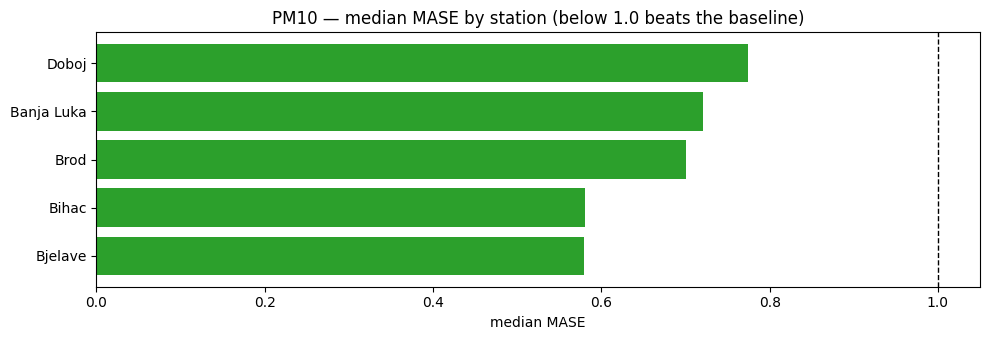

saved xlstm_mase_by_station.png


In [4]:
run_all(limit=5)
plot_results()

In [5]:
progress()

95 total pairs
5 done
90 remaining (18 more batches of 5)

next up: [('Gacko', 'pm10'), ('Ilidza', 'pm10'), ('Ilijas', 'pm10'), ('Isedlo', 'pm10'), ('Livno', 'pm10')]


([('Banja Luka', 'pm10'),
  ('Bihac', 'pm10'),
  ('Bjelave', 'pm10'),
  ('Brod', 'pm10'),
  ('Doboj', 'pm10'),
  ('Gacko', 'pm10'),
  ('Ilidza', 'pm10'),
  ('Ilijas', 'pm10'),
  ('Isedlo', 'pm10'),
  ('Livno', 'pm10'),
  ('Mostar', 'pm10'),
  ('Otoka', 'pm10'),
  ('Trebinje', 'pm10'),
  ('Tuzla-Trnovac', 'pm10'),
  ('Vijecnica', 'pm10'),
  ('Vogosca', 'pm10'),
  ('Ambasada', 'pm25'),
  ('Banja Luka', 'pm25'),
  ('Bihac', 'pm25'),
  ('Bjelave', 'pm25'),
  ('Brod', 'pm25'),
  ('Ilidza', 'pm25'),
  ('Livno', 'pm25'),
  ('Mostar', 'pm25'),
  ('Trebinje', 'pm25'),
  ('Tuzla-BKC', 'pm25'),
  ('Tuzla-Skver', 'pm25'),
  ('Vogosca', 'pm25'),
  ('Banja Luka', 'so2'),
  ('Bihac', 'so2'),
  ('Bjelave', 'so2'),
  ('Brod', 'so2'),
  ('Doboj', 'so2'),
  ('Gacko', 'so2'),
  ('Hadzici', 'so2'),
  ('Ilidza', 'so2'),
  ('Ilijas', 'so2'),
  ('Isedlo', 'so2'),
  ('Livno', 'so2'),
  ('Mostar', 'so2'),
  ('Otoka', 'so2'),
  ('Prijedor', 'so2'),
  ('Trebinje', 'so2'),
  ('Tuzla-BKC', 'so2'),
  ('Tuzla-Bukinje

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

5 station-pollutant pairs already in xlstm_results.csv, skipping those
95 total pairs, 90 remaining
running this batch: [('Gacko', 'pm10'), ('Ilidza', 'pm10'), ('Ilijas', 'pm10'), ('Isedlo', 'pm10'), ('Livno', 'pm10')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Gacko-pm10] epoch 1: train MAE (normalized)=8168.9623
[Gacko-pm10] epoch 2: train MAE (normalized)=0.5034
[Gacko-pm10] epoch 3: train MAE (normalized)=0.4800
[Gacko-pm10] epoch 4: train MAE (normalized)=0.4704
[Gacko-pm10] epoch 5: train MAE (normalized)=0.4650
[Gacko-pm10] epoch 6: train MAE (normalized)=0.4620
[Gacko-pm10] epoch 7: train MAE (normalized)=0.4588
[Gacko-pm10] epoch 8: train MAE (normalized)=0.4557
[Gacko-pm10] epoch 9: train MAE (normalized)=0.4563
[Gacko-pm10] epoch 10: train MAE (normalized)=0.4545
[Gacko-pm10] epoch 11: train MAE (normalized)=0.4523
[Gacko-pm10] epoch 12: train MAE (normalized)=0.4504
[Gacko-pm10] epoch 13: train MAE (normalized)=0.4492
[Gacko-pm10] epoch 14: train MAE (normalized)=0.4482
[Gacko-pm10] epoch 15: train MAE (normalized)=0.4470
[Gacko-pm10] epoch 16: train MAE (normalized)=0.4453
[Gacko-pm10] epoch 17: train MAE (normalized)=0.4432
[Gacko-pm10] epoch 18: train MAE (normalized)=0.4439
[Gacko-pm10] epoch 19: train MAE (normalized)=0.4400

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

...

[Ilijas-pm10] epoch 1: train MAE (normalized)=27353.1394
[Ilijas-pm10] epoch 2: train MAE (normalized)=42.3753
[Ilijas-pm10] epoch 3: train MAE (normalized)=0.4437
[Ilijas-pm10] epoch 4: train MAE (normalized)=0.4326
[Ilijas-pm10] epoch 5: train MAE (normalized)=0.4279
[Ilijas-pm10] epoch 6: train MAE (normalized)=0.4259
[Ilijas-pm10] epoch 7: train MAE (normalized)=0.4223
[Ilijas-pm10] epoch 8: train MAE (normalized)=0.4221
[Ilijas-pm10] epoch 9: train MAE (normalized)=0.4207
[Ilijas-pm10] epoch 10: train MAE (normalized)=0.4162
[Ilijas-pm10] epoch 11: train MAE (normalized)=0.4172
[Ilijas-pm10] epoch 12: train MAE (normalized)=0.4157
[Ilijas-pm10] epoch 13: train MAE (normalized)=0.4141
[Ilijas-pm10] epoch 14: train MAE (normalized)=0.6152
[Ilijas-pm10] epoch 15: train MAE (normalized)=0.4143
[Ilijas-pm10] epoch 16: train MAE (normalized)=0.4125
[Ilijas-pm10] epoch 17: train MAE (normalized)=0.4143
[Ilijas-pm10] epoch 18: train MAE (normalized)=0.4158
[Ilijas-pm10] epoch 19: train MA

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Isedlo-pm10] epoch 1: train MAE (normalized)=24356.8544
[Isedlo-pm10] epoch 2: train MAE (normalized)=0.4706
[Isedlo-pm10] epoch 3: train MAE (normalized)=0.4000
[Isedlo-pm10] epoch 4: train MAE (normalized)=0.3871
[Isedlo-pm10] epoch 5: train MAE (normalized)=0.3814
[Isedlo-pm10] epoch 6: train MAE (normalized)=0.3788
[Isedlo-pm10] epoch 7: train MAE (normalized)=0.3814
[Isedlo-pm10] epoch 8: train MAE (normalized)=0.3774
[Isedlo-pm10] epoch 9: train MAE (normalized)=0.3738
[Isedlo-pm10] epoch 10: train MAE (normalized)=0.3720
[Isedlo-pm10] epoch 11: train MAE (normalized)=0.3699
[Isedlo-pm10] epoch 12: train MAE (normalized)=0.3688
[Isedlo-pm10] epoch 13: train MAE (normalized)=0.3680
[Isedlo-pm10] epoch 14: train MAE (normalized)=480.8720
[Isedlo-pm10] epoch 15: train MAE (normalized)=151.8147
[Isedlo-pm10] epoch 16: train MAE (normalized)=0.3665
[Isedlo-pm10] epoch 17: train MAE (normalized)=0.3708
[Isedlo-pm10] epoch 18: train MAE (normalized)=0.3647
[Isedlo-pm10] epoch 19: train

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Livno-pm10] epoch 1: train MAE (normalized)=20892.7499
[Livno-pm10] epoch 2: train MAE (normalized)=0.5064
[Livno-pm10] epoch 3: train MAE (normalized)=0.4640
[Livno-pm10] epoch 4: train MAE (normalized)=0.4478
[Livno-pm10] epoch 5: train MAE (normalized)=0.4385
[Livno-pm10] epoch 6: train MAE (normalized)=0.4336
[Livno-pm10] epoch 7: train MAE (normalized)=0.4309
[Livno-pm10] epoch 8: train MAE (normalized)=0.4276
[Livno-pm10] epoch 9: train MAE (normalized)=0.4266
[Livno-pm10] epoch 10: train MAE (normalized)=0.4245
[Livno-pm10] epoch 11: train MAE (normalized)=0.4234
[Livno-pm10] epoch 12: train MAE (normalized)=0.4232
[Livno-pm10] epoch 13: train MAE (normalized)=0.4215
[Livno-pm10] epoch 14: train MAE (normalized)=0.4225
[Livno-pm10] epoch 15: train MAE (normalized)=0.4222
[Livno-pm10] epoch 16: train MAE (normalized)=0.4212
[Livno-pm10] epoch 17: train MAE (normalized)=0.4205
[Livno-pm10] epoch 18: train MAE (normalized)=8.6224
[Livno-pm10] epoch 19: train MAE (normalized)=0.417

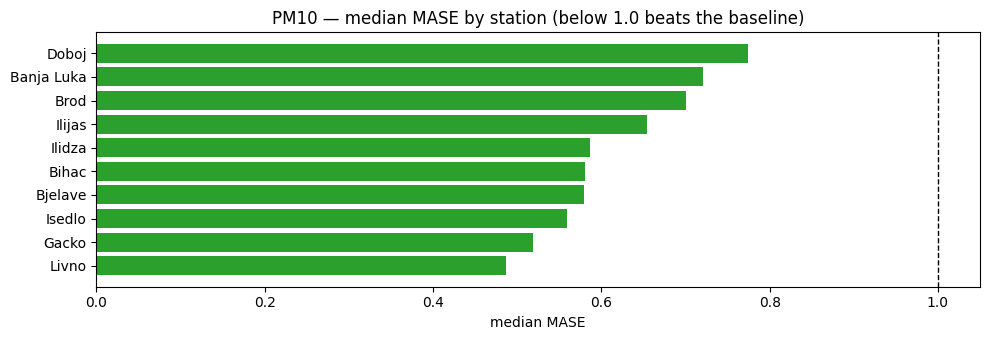

saved xlstm_mase_by_station.png


In [ ]:
run_all(limit=5)
plot_results()

In [ ]:
progress()

95 total pairs
10 done
85 remaining (17 more batches of 5)

next up: [('Mostar', 'pm10'), ('Otoka', 'pm10'), ('Trebinje', 'pm10'), ('Tuzla-Trnovac', 'pm10'), ('Vijecnica', 'pm10')]


([('Banja Luka', 'pm10'),
  ('Bihac', 'pm10'),
  ('Bjelave', 'pm10'),
  ('Brod', 'pm10'),
  ('Doboj', 'pm10'),
  ('Gacko', 'pm10'),
  ('Ilidza', 'pm10'),
  ('Ilijas', 'pm10'),
  ('Isedlo', 'pm10'),
  ('Livno', 'pm10'),
  ('Mostar', 'pm10'),
  ('Otoka', 'pm10'),
  ('Trebinje', 'pm10'),
  ('Tuzla-Trnovac', 'pm10'),
  ('Vijecnica', 'pm10'),
  ('Vogosca', 'pm10'),
  ('Ambasada', 'pm25'),
  ('Banja Luka', 'pm25'),
  ('Bihac', 'pm25'),
  ('Bjelave', 'pm25'),
  ('Brod', 'pm25'),
  ('Ilidza', 'pm25'),
  ('Livno', 'pm25'),
  ('Mostar', 'pm25'),
  ('Trebinje', 'pm25'),
  ('Tuzla-BKC', 'pm25'),
  ('Tuzla-Skver', 'pm25'),
  ('Vogosca', 'pm25'),
  ('Banja Luka', 'so2'),
  ('Bihac', 'so2'),
  ('Bjelave', 'so2'),
  ('Brod', 'so2'),
  ('Doboj', 'so2'),
  ('Gacko', 'so2'),
  ('Hadzici', 'so2'),
  ('Ilidza', 'so2'),
  ('Ilijas', 'so2'),
  ('Isedlo', 'so2'),
  ('Livno', 'so2'),
  ('Mostar', 'so2'),
  ('Otoka', 'so2'),
  ('Prijedor', 'so2'),
  ('Trebinje', 'so2'),
  ('Tuzla-BKC', 'so2'),
  ('Tuzla-Bukinje

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
os.makedirs('/content/drive/MyDrive/xlstm_checkpoints', exist_ok=True)
shutil.copy('xlstm_results.csv', '/content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv')
print("backed up to Drive")

In [ ]:
CSV = '/content/drive/MyDrive/xlstm_checkpoints/xlstm_results.csv'
run_all(limit=5, out_csv=CSV)
plot_results(out_csv=CSV)

In [ ]:
def final_summary(out_csv="xlstm_results.csv"):
    full = pd.read_csv(out_csv)

    print(f"{len(full):,} total windows across "
          f"{full.groupby(['station', 'pollutant']).ngroups} station-pollutant series\n")

    per_pol = full.groupby("pollutant")[["mae", "rmse", "mase"]].mean()
    per_pol["median_mase"] = full.groupby("pollutant").mase.median()
    print("MASE BY POLLUTANT (mean + median — median is the trustworthy one)\n")
    print(per_pol.round(3).to_string())

    print(f"\n\nHEADLINE — mean over all windows: "
          f"MAE {full.mae.mean():.3f}  RMSE {full.rmse.mean():.3f}  MASE {full.mase.mean():.3f}")
    print(f"HEADLINE — median MASE over all windows: {full.mase.median():.3f}")

    base_path = os.path.join(SHARED_DIR, "baseline_windows.csv")
    if os.path.exists(base_path):
        base = pd.read_csv(base_path, parse_dates=["origin"])
        full2 = full.copy()
        if "origin" in full2.columns:
            full2["origin"] = pd.to_datetime(full2.origin)
        key = ["station", "pollutant", "origin"]
        base = base.merge(full2[key].assign(_keep=1), on=key, how="inner").drop(columns="_keep")
        allm = pd.concat([base, full2.assign(model="xlstm")[base.columns.intersection(full2.columns) | {"model"}]],
                          ignore_index=True)
        print("\n\nMASE BY POLLUTANT vs BASELINES (identical windows)\n")
        pivot = allm.pivot_table(index="pollutant", columns="model", values="mase")
        print(pivot.round(3).to_string())
    else:
        print(f"\n(no {base_path} found — skipping baseline merge; "
              "per-pollutant numbers above are still valid on their own)")

    return per_pol


final_summary()